# Notebook for all simulations

In [1]:
# %load_ext autoreload
# %autoreload 2

In [2]:
import numpy as np
import pandas as pd
import pickle
from tqdm import tqdm
import matplotlib.pyplot as plt

from check_warmup import avg_warmup_count, plot_avg_warmup_count

from environment import GLMBandit

from glmbanditexp.algorithms.ecolog import EcoLog
from glmbanditexp.algorithms.gloc import Gloc
from glmbanditexp.algorithms.glm_ucb import GlmUCB
from glmbanditexp.algorithms.rs_glinucb import RS_GLinUCB
from glmbanditexp.algorithms.private_rs_glinucb import Private_RS_GLinUCB
from glmbanditexp.algorithms.ofulogplus import OFULogPlus
from simulation_utils import plot_regret, simulate_with_epsilon

### Warm-up Count for Rarely-Switching GLBandit

In [3]:
num_trials = 5
d=5
K=10
T=5000
kappa=50.0
R=1.0
S=5.0
lmbda=20.0
seed=186329

Running trial 1


100%|██████████| 5000/5000 [00:00<00:00, 18373.57it/s]


Running trial 2


100%|██████████| 5000/5000 [00:00<00:00, 20791.05it/s]


Running trial 3


100%|██████████| 5000/5000 [00:00<00:00, 20924.90it/s]


Running trial 4


100%|██████████| 5000/5000 [00:00<00:00, 21111.83it/s]


Running trial 5


100%|██████████| 5000/5000 [00:00<00:00, 20107.62it/s]


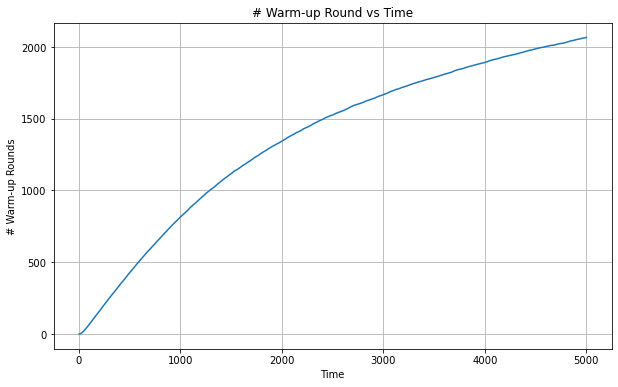

In [10]:
count = avg_warmup_count(num_trials, d, K, T, kappa, R, S, lmbda, seed)
plot_avg_warmup_count(count, show_flag=True)

## Regret Simulations

In [ ]:
# # Modified simulate function with epsilon array support
# def simulate_with_epsilon(num_trials, env, algo_names_list, delta, epsilon_arr=[8, 6, 4, 2], seed=None):
#     regret_dict = {}
#     # Create a single rng for all trials
#     if seed is not None:
#         rng = np.random.default_rng(seed)
#     else:
#         rng = np.random.default_rng()
        
#     for n in range(num_trials):
#         algo_arr = []
#         algo_eps_mapping = []  # Track which epsilon each algorithm uses
#         print('Simulating trial', n+1)
#         for k in algo_names_list:
#             if k == 'Private-GLM':
#                 # Create multiple Private-RS-GLinUCB instances with different epsilon values
#                 for eps in epsilon_arr:
#                     algo = Private_RS_GLinUCB(env.get_first_action_set(), env.kappa, env.kappa_star, 
#                                            env.R, env.S, env.model, env.T, delta, eps, 2e-2, rng=rng)
#                     algo_arr.append(algo)
#                     algo_eps_mapping.append(eps)  # Track the epsilon for this algorithm
#             elif k == 'RS-GLinUCB':
#                 algo = RS_GLinUCB(env.get_first_action_set(), env.kappa, env.R, env.S, env.model, env.T, delta, rng=rng)
#                 algo_arr.append(algo)
#                 algo_eps_mapping.append(None)  # No epsilon for non-private algorithms
#             elif k == 'GLOC':
#                 algo = Gloc(env.get_first_action_set(), env.kappa, env.R, env.S, env.model, delta, rng=rng)
#                 algo_arr.append(algo)
#                 algo_eps_mapping.append(None)
#             elif k == 'GLM-UCB':
#                 algo = GlmUCB(env.get_first_action_set(), env.kappa, env.R, env.S, env.model, env.T, delta, rng=rng)
#                 algo_arr.append(algo)
#                 algo_eps_mapping.append(None)
#             elif k == 'EcoLog':
#                 algo = EcoLog(env.get_first_action_set(), env.kappa, env.R, env.S, env.model, delta, rng=rng)
#                 algo_arr.append(algo)
#                 algo_eps_mapping.append(None)
#             elif k == 'OfuLog+':
#                 algo = OFULogPlus(env.get_first_action_set(), env.kappa, env.R, env.S, env.model, env.T, delta, rng=rng)
#                 algo_arr.append(algo)
#                 algo_eps_mapping.append(None)

#         print("Algorithm mapping:")
#         for j, (algo, eps) in enumerate(zip(algo_arr, algo_eps_mapping)):
#             print(f"  Index {j}: {algo.name} -> ε={eps}")
    
#         for t in tqdm(range(env.T)):
#             act_arr = []
#             for algo in algo_arr:
#                 act_arr.append(algo.play_arm())
#             try:
#                 rewards, regrets, next_arm_set = env.step(act_arr)
#             except:
#                 raise ValueError("No action  in next time step")

#             for j, algo in enumerate(algo_arr):                
#                 algo.update(rewards[j], regrets[j], next_arm_set)
        
#         # Store results for each algorithm with proper naming
#         for j, algo in enumerate(algo_arr):
#             # Check if this is a Private-RS-GLinUCB algorithm by checking the algorithm name
#             if 'Private-GLM' in algo.name:
#                 # Use the tracked epsilon value
#                 eps = algo_eps_mapping[j]
#                 algo_name = f'Private-GLM (ε={eps})'
#             else:
#                 algo_name = algo.name
            
#             if algo_name not in regret_dict.keys():
#                 regret_dict[algo_name] = np.array(algo.regret_arr)
#             else:
#                 regret_dict[algo_name] += np.array(algo.regret_arr)
#         env.reset()
    
#     for k in regret_dict.keys():
#         regret_dict[k] /= num_trials
    
#     return regret_dict

In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt

# def plot_regret(rg_dict, T, filename):
#     fig, ax = plt.subplots(1, 1, figsize=(6, 4))
#     T_arr = np.arange(1, T+1)

#     # Baseline colors (use tab10, safe and distinct)
#     baseline_colors = plt.cm.tab10.colors
#     baseline_map = {}

#     # Use a distinct colormap for Private-GLM (e.g. Set2 or Dark2)
#     private_colors = plt.cm.Set2(np.linspace(0, 1, 4))
#     private_markers = ['o', 's', '^', 'D']
#     private_linestyles = ['-', '--', '-.', ':']

#     for i, k in enumerate(sorted(rg_dict.keys())):
#         if "Private-GLM" in k:
#             try:
#                 eps = int(k.split('ε=')[1].split(')')[0])
#             except Exception:
#                 eps = 2
#             idx = (eps // 2 - 1) % 4
#             ax.plot(
#                 T_arr, np.cumsum(rg_dict[k]),
#                 color=private_colors[idx],
#                 linestyle=private_linestyles[idx % len(private_linestyles)],
#                 linewidth=2,
#                 marker=private_markers[idx],
#                 markersize=4,
#                 markevery=max(1, T // 25),
#                 label=k
#             )
#         else:
#             if k not in baseline_map:
#                 baseline_map[k] = baseline_colors[len(baseline_map) % len(baseline_colors)]
#             ax.plot(
#                 T_arr, np.cumsum(rg_dict[k]),
#                 color=baseline_map[k],
#                 linestyle='-',
#                 linewidth=2,
#                 label=k
#             )

#     # Single clean legend (no cutoff issues)
#     ax.legend(
#         fontsize=11, framealpha=0.9,
#         loc='center left', bbox_to_anchor=(1.02, 0.5),
#         borderaxespad=0
#     )

#     ax.grid(True, alpha=0.3)
#     ax.set_xlabel('# of Rounds', fontsize=14)
#     ax.set_ylabel('Cumulative Regret', fontsize=14)
#     ax.set_title('Cumulative Regret vs # of Rounds', fontsize=16)

#     plt.tight_layout()
#     plt.savefig(filename, dpi=600, bbox_inches='tight')
#     plt.show()


### Logistic Model Simulation

In [4]:
config = {"full_norm": True}
config['seed'] = 109832
config['model'] = 'Logistic'
config['theta_dim'] = 5
config['num_arms'] = 20
config['theta_norm'] = 3.5
config['horizon_length'] = 15000

env = GLMBandit(config=config)
print('Kappa =', env.kappa)
print('Theta =' , env.theta)

Calculating kappa...


100%|██████████| 15000/15000 [00:00<00:00, 43498.31it/s]


Calculating kappa star...


100%|██████████| 15000/15000 [00:00<00:00, 47637.46it/s]


Kappa = 33.76245430799423
Theta = [ 0.33611642  2.07824585  0.86373033  0.29158908 -2.64326799]


In [12]:
algo_names_list = ['RS-GLinUCB', 'EcoLog', 'GLOC', 'Private-GLM']
num_trials = 10

# Export lambda_max histories to a dedicated directory
regret_dict = simulate_with_epsilon(
    num_trials, env, algo_names_list, 0.02, 
    epsilon_arr=[1, 2, 4, 8], 
    seed=109832,
    export_lambda_histories_dir='./Results/lambda_histories_logistic_uniform_split'
)
with open('./Results/test_experiment_logistic_uniform_split.pickle', 'wb') as f:
    pickle.dump(regret_dict, f)
plot_regret(regret_dict, env.T, './Results/test_Logistic_Regret.png')
##plot_regret(regret_dict, env.T, './Results/Logistic_Regret.png')

Simulating trial 1
Lambda is  55.92796067487144 for non-private glinucb
Lambda: 645.1831354566327 private rs glinucb
Count1 cutoff: 67, Count2 cutoff: 7
Lambda: 350.5555480657521 private rs glinucb
Count1 cutoff: 67, Count2 cutoff: 7
Lambda: 203.24175437031175 private rs glinucb
Count1 cutoff: 67, Count2 cutoff: 7
Lambda: 129.58485752259162 private rs glinucb
Count1 cutoff: 67, Count2 cutoff: 6
Algorithm mapping:
  Index 0: RS-GLinUCB (Sawarni et al. 2024)
  Index 1: ECOLog (Faury et al. 2022)
  Index 2: GLOC (Jun et al. 2017)
  Index 3: Private-GLM (This work) -> ε=1
  Index 4: Private-GLM (This work) -> ε=2
  Index 5: Private-GLM (This work) -> ε=4
  Index 6: Private-GLM (This work) -> ε=8


  3%|▎         | 485/15000 [00:02<01:18, 185.56it/s]

Counter 2 switching at 464 for non-private RS-glinucb


  7%|▋         | 1083/15000 [00:06<01:23, 165.92it/s]

Counter 2 switching at 1048 for non-private RS-glinucb


...

Counter 2 switching at 3449 for non-private RS-glinucb


 30%|███       | 4543/15000 [07:39<1:24:43,  2.06it/s]

Counter 2 switching at 4527 for non-private RS-glinucb


 32%|███▏      | 4863/15000 [09:18<19:24,  8.71it/s]  


KeyboardInterrupt: 

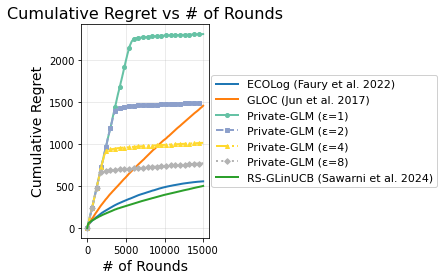

In [5]:
with open('./Results/test_experiment_logistic_uniform_split.pickle', 'rb') as f:
    regret_dict = pickle.load(f)
plot_regret(regret_dict, env.T, './Results/test_Logistic_Regret_temp.png')

### Probit Model Simulation

In [6]:
config = {}
config['seed'] = 109832
config['model'] = 'Probit'
config['theta_dim'] = 5
config['num_arms'] = 20
config['theta_norm'] = 3.0
config['horizon_length'] = 5000
config['full_norm'] = True

env = GLMBandit(config=config)
print('Kappa =', env.kappa)
print('Theta =' , env.theta)

Calculating kappa...


100%|██████████| 5000/5000 [00:00<00:00, 56267.06it/s]


Calculating kappa star...


100%|██████████| 5000/5000 [00:00<00:00, 41883.31it/s]


Kappa = 193.18410051249518
Theta = [ 0.28809979  1.78135359  0.74034028  0.2499335  -2.26565828]


Simulating trial 1
Lambda is  51.808164592366026 for non-private glinucb
Lambda: 858.693659559738 private rs glinucb
Count1 cutoff: 230, Count2 cutoff: 8
Lambda: 455.25091207605203 private rs glinucb
Count1 cutoff: 230, Count2 cutoff: 7
Lambda: 253.529538334209 private rs glinucb
Count1 cutoff: 230, Count2 cutoff: 7
Lambda: 152.66885146328752 private rs glinucb
Count1 cutoff: 230, Count2 cutoff: 6
Algorithm mapping:
  Index 0: RS-GLinUCB (Sawarni et al. 2024)
  Index 1: GLM-UCB (Filippi et al. 2010)
  Index 2: GLOC (Jun et al. 2017)
  Index 3: Private-GLM (This work) -> ε=1
  Index 4: Private-GLM (This work) -> ε=2
  Index 5: Private-GLM (This work) -> ε=4
  Index 6: Private-GLM (This work) -> ε=8


  0%|          | 7/5000 [00:00<01:16, 65.41it/s]/Users/sahasrajitsarmasarkar/Downloads/AiStats_appendix/Code/glmbanditexp/utils/utils.py:373: RuntimeWarning: divide by zero encountered in log
  return - np.sum(Y * np.log(probit(np.dot(X, theta))) + (1 - Y) * np.log(1 - probit(np.dot(X, theta)))) + lmbda * np.sum(np.square(theta))
/Users/sahasrajitsarmasarkar/Downloads/AiStats_appendix/Code/glmbanditexp/utils/utils.py:373: RuntimeWarning: invalid value encountered in multiply
  return - np.sum(Y * np.log(probit(np.dot(X, theta))) + (1 - Y) * np.log(1 - probit(np.dot(X, theta)))) + lmbda * np.sum(np.square(theta))
 46%|████▌     | 2296/5000 [00:40<00:52, 51.19it/s]

Counter 2 switching at 2291 for non-private RS-glinucb


 97%|█████████▋| 4867/5000 [10:21<09:05,  4.10s/it]  

Counter 2 switching at 4863 for non-private RS-glinucb


100%|██████████| 5000/5000 [12:21<00:00,  6.74it/s]


Max logdet curr H: 34.74365967121233, Max logdet prev H: 34.71141065745366 epsilon 1 delta 0.02
Counter1 final: 0, Counter2 final: 1 epsilon 1 delta 0.02
Max logdet curr H: 32.08633815093355, Max logdet prev H: 31.90497703111102 epsilon 2 delta 0.02
Counter1 final: 0, Counter2 final: 2 epsilon 2 delta 0.02
Max logdet curr H: 29.870962278224667, Max logdet prev H: 29.108073685231112 epsilon 4 delta 0.02
Counter1 final: 0, Counter2 final: 2 epsilon 4 delta 0.02
Max logdet curr H: 28.231072558028732, Max logdet prev H: 28.131218407620626 epsilon 8 delta 0.02
Counter1 final: 0, Counter2 final: 4 epsilon 8 delta 0.02
[Private-GLM] Exported lambda history to ./Results/lambda_histories_probit_uniform_split/lambda_history_trial1_eps1.json
  Max λ_max: 1.330741, Num triggers: 1
[Private-GLM] Exported lambda history to ./Results/lambda_histories_probit_uniform_split/lambda_history_trial1_eps2.json
  Max λ_max: 1.343619, Num triggers: 2
[Private-GLM] Exported lambda history to ./Results/lambda_hi

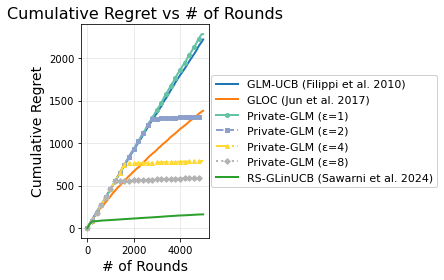

In [ ]:
algo_names_list = ['RS-GLinUCB', 'GLM-UCB', 'GLOC', 'Private-GLM']
num_trials = 10

# Export lambda_max histories to a dedicated directory
regret_dict = simulate_with_epsilon(
    num_trials, env, algo_names_list, 0.02, 
    epsilon_arr=[1, 2, 4, 8], 
    seed=10345,
    export_lambda_histories_dir='./Results/lambda_histories_probit_uniform_split'
)
with open('./Results/experiment_probit_uniform_split.pickle', 'wb') as f:
    pickle.dump(regret_dict, f)
plot_regret(regret_dict, env.T, './Results/Probit_Regret.png')

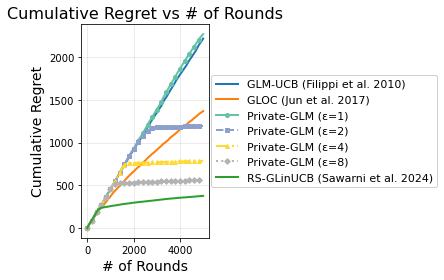

In [7]:
with open('./Results/experiment_probit_uniform_split.pickle', 'rb') as f:
    regret_dict = pickle.load(f)
plot_regret(regret_dict, env.T, './Results/Probit_Regret_temp.png')